In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "Image"
MASK_DIR = DATA_DIR / "Mask"
SPLIT_CSV = DATA_DIR / "split.csv"

IMG_SIZE = 256
MEAN = (0.485, 0.456, 0.406)   # ImageNet stats, for the pretrained encoder
STD = (0.229, 0.224, 0.225)

In [2]:
images = sorted(IMAGE_DIR.glob("*"))
stems = [p.stem for p in images]

train, temp = train_test_split(stems, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

rows = [(s, "train") for s in train] + [(s, "val") for s in val] + [(s, "test") for s in test]
pd.DataFrame(rows, columns=["stem", "split"]).to_csv(SPLIT_CSV, index=False)

print(len(train), len(val), len(test))

203 43 44


In [3]:
def get_transforms(train):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomBrightnessContrast(p=0.3),
            A.Normalize(mean=MEAN, std=STD),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])


class FloodDataset(Dataset):
    def __init__(self, split, train=False):
        df = pd.read_csv(SPLIT_CSV)
        self.stems = df[df.split == split].stem.astype(str).tolist()
        self.img_paths = {p.stem: p for p in IMAGE_DIR.glob("*")}
        self.mask_paths = {p.stem: p for p in MASK_DIR.glob("*")}
        self.tf = get_transforms(train)

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        s = self.stems[i]
        img = np.array(Image.open(self.img_paths[s]).convert("RGB"))
        msk = (np.array(Image.open(self.mask_paths[s]).convert("L")) > 127).astype(np.uint8)
        out = self.tf(image=img, mask=msk)
        return out["image"], out["mask"].unsqueeze(0).float()   # mask: (1, H, W)
    

In [4]:
train_ds = FloodDataset("train", train=True)
val_ds = FloodDataset("val", train=False)
test_ds = FloodDataset("test", train=False)

x, y = train_ds[0]
print(len(train_ds), len(val_ds), len(test_ds))
print(x.shape, y.shape, y.unique())
# expected: torch.Size([3, 256, 256]) torch.Size([1, 256, 256]) tensor([0., 1.])

203 43 44
torch.Size([3, 256, 256]) torch.Size([1, 256, 256]) tensor([0., 1.])


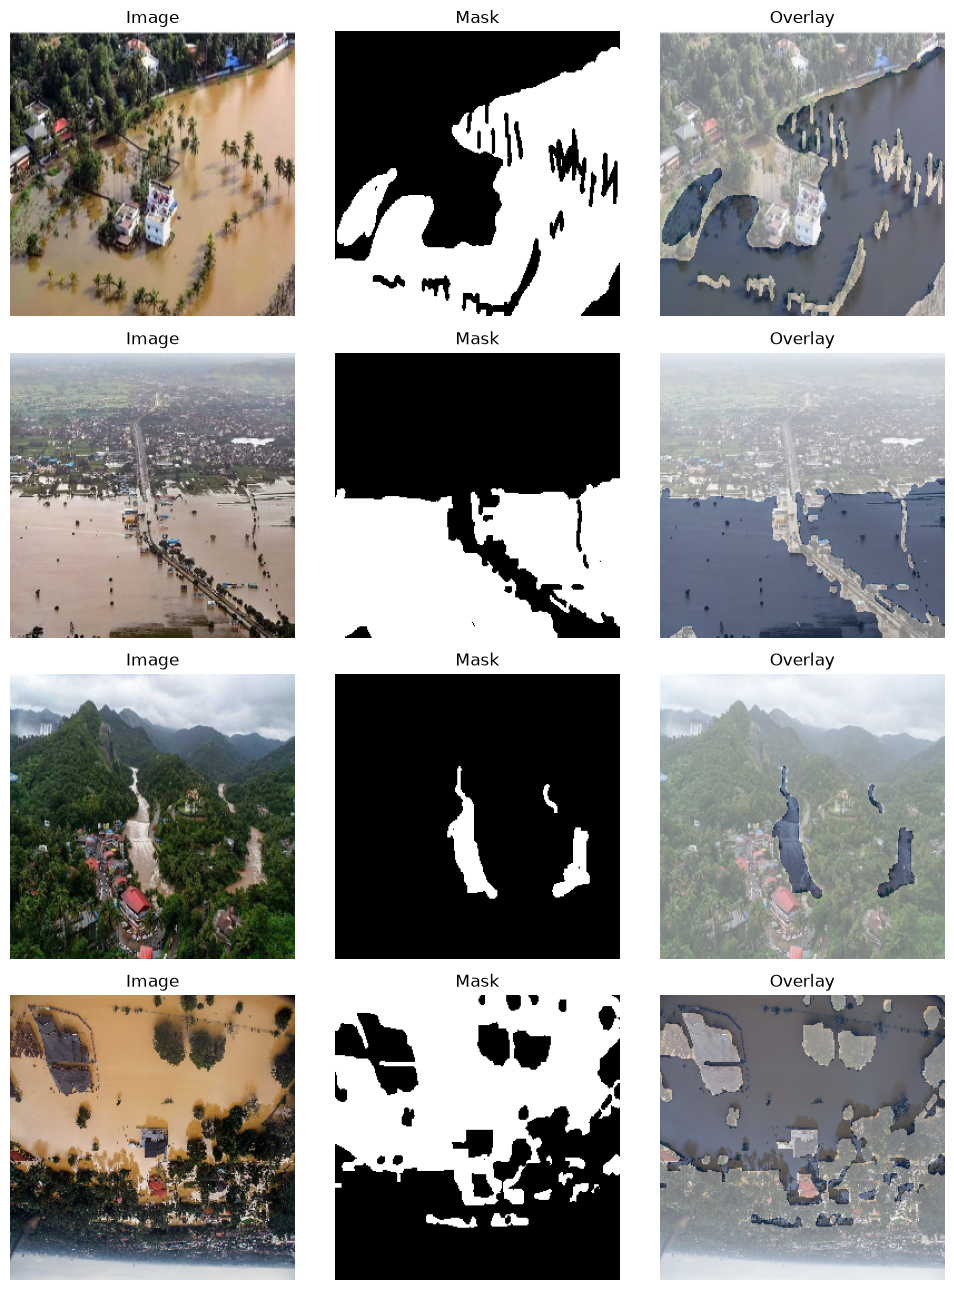

In [5]:
def denormalize(t):
    img = t.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for row in range(4):
    x, y = train_ds[row]   # random augmentation each call
    axes[row, 0].imshow(denormalize(x))
    axes[row, 0].set_title("Image")
    axes[row, 1].imshow(y[0], cmap="gray")
    axes[row, 1].set_title("Mask")
    axes[row, 2].imshow(denormalize(x))
    axes[row, 2].imshow(y[0], cmap="Blues", alpha=0.5)
    axes[row, 2].set_title("Overlay")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)   # [8, 3, 256, 256] and [8, 1, 256, 256]

torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256])


In [3]:
from pathlib import Path
from PIL import Image

image_dir = Path("../data/Image")
mask_dir = Path("../data/Mask")

print(image_dir.exists(), mask_dir.exists())   # must print: True True

imgs = {p.stem: p for p in image_dir.glob("*")}
msks = {p.stem: p for p in mask_dir.glob("*")}
print(len(imgs), len(msks))                    # must print: 290 290

bad = []
for s in sorted(imgs):
    wi, hi = Image.open(imgs[s]).size
    wm, hm = Image.open(msks[s]).size
    if (wi, hi) != (wm, hm):
        bad.append(s)
        print(s, "image:", (wi, hi), "mask:", (wm, hm))

print("Mismatched pairs:", len(bad), "of", len(imgs))

True True
290 290
1061 image: (660, 440) mask: (700, 389)
1079 image: (1024, 682) mask: (759, 422)
14 image: (1900, 1425) mask: (1024, 630)
15 image: (1024, 630) mask: (1900, 1425)
2052 image: (1012, 490) mask: (1200, 800)
2053 image: (1200, 800) mask: (1012, 490)
3059 image: (650, 400) mask: (1920, 1005)
Mismatched pairs: 7 of 290


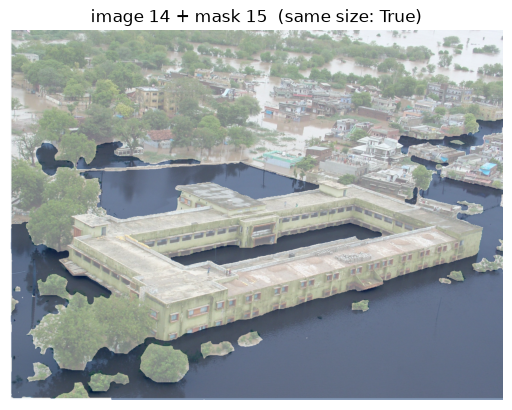

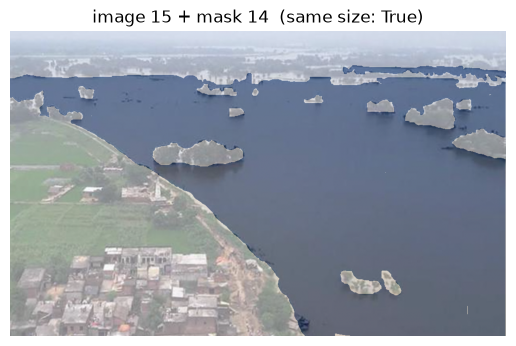

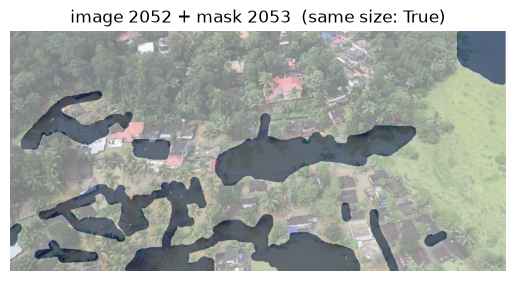

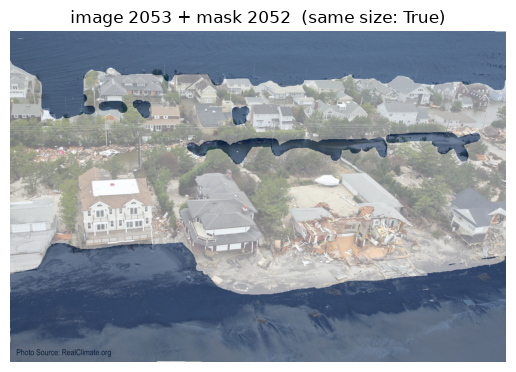

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show(img_stem, mask_stem):
    img = Image.open(imgs[img_stem]).convert("RGB")
    msk = Image.open(msks[mask_stem]).convert("L")
    ok = img.size == msk.size
    plt.imshow(img)
    if ok:
        plt.imshow(np.array(msk) > 127, cmap="Blues", alpha=0.5)
    plt.title(f"image {img_stem} + mask {mask_stem}  (same size: {ok})")
    plt.axis("off"); plt.show()

show("14", "15"); show("15", "14"); show("2052", "2053"); show("2053", "2052")

In [ ]:
df = pd.read_csv("../data/split.csv")
df = df[~df.stem.astype(str).isin(["1061", "1079", "3059"])]
df.to_csv("../data/split.csv", index=False)
print(df.split.value_counts())

split
train    202
test      43
val       42
Name: count, dtype: int64
